In [1]:
graphics_toolkit("gnuplot");


The FLTK graphics toolkit is not actively maintained and has a number
of limitations that are unlikely to be fixed.
The qt toolkit is recommended instead.


The gnuplot graphics toolkit is not actively maintained and has a number
of limitations that are unlikely to be fixed.  Communication with gnuplot
uses a one-directional pipe and limited information is passed back to the
Octave interpreter so most changes made interactively in the plot window
will not be reflected in the graphics properties managed by Octave.  For
example, if the plot window is closed with a mouse click, Octave will not
be notified and will not update its internal list of open figure windows.
The qt toolkit is recommended instead.


In [2]:
function x = tridiag_solve(a, b, c, d)
    n = length(d);
    for i = 2:n
        w = a(i-1) / b(i-1);
        b(i) = b(i) - w * c(i-1);
        d(i) = d(i) - w * d(i-1);
    end
    x = zeros(n,1);
    x(n) = d(n) / b(n);
    for i = n-1:-1:1
        x(i) = (d(i) - c(i) * x(i+1)) / b(i);
    end
end

a = 0; b = 1;
k = @(x) x.^2 + 1;
q = @(x) x + 1;
f = @(x) x.^5 - 21*x.^4 + 23*x.^3 - 14*x.^2 + 9*x - 2;

u_exact = @(x) x.^4 - 2*x.^3 + x.^2 + 3*x;

tol = 1e-4;
N = 5;
err_est = tol + 1;
first = true;

while err_est > tol
    h = (b - a)/(N - 1);
    x = linspace(a, b, N)';
    xmid = (x(1:end-1) + x(2:end))/2;
    
    kmid = k(xmid);
    qv = q(x);
    fv = f(x);
    
    a_diag = zeros(N,1);
    b_diag = zeros(N,1);
    c_diag = zeros(N,1);
    d_vec = zeros(N,1);
    
    for i = 2:N-1
        a_diag(i-1) = -kmid(i-1)/h^2;
        c_diag(i)   = -kmid(i)/h^2;
        b_diag(i)   = (kmid(i-1) + kmid(i))/h^2 + qv(i);
        d_vec(i)    = fv(i);
    end
    
    b_diag(1) = 1; c_diag(1) = 0; d_vec(1) = u_exact(0);
    a_diag(N-1) = 0; b_diag(N) = 1; d_vec(N) = u_exact(1);
    
    aa = a_diag(1:N-1);
    cc = c_diag(1:N-1);
    
    U = tridiag_solve(aa, b_diag, cc, d_vec);
    
    if ~first
    U_coarse = U(1:2:end);
    err_est = max(abs(U_coarse - U_prev)) / 3;
    fprintf('N = %d, h = %.6f, оценка погрешности = %.6e\n', N, h, err_est);
        if err_est < tol
            x_final1 = x;
            U_final1 = U;
            break;
        end
    else
        first = false;
    end
    
    U_prev = U;
    N = 2*N - 1;
end

x_final1 = x;
U_final1 = U;


N = 9, h = 0.125000, оценка погрешности = 3.374646e-03
N = 17, h = 0.062500, оценка погрешности = 8.679494e-04
N = 33, h = 0.031250, оценка погрешности = 2.195086e-04
N = 65, h = 0.015625, оценка погрешности = 5.504119e-05


In [3]:
n = length(x_final1);
A_full = zeros(n, n);

% Главная диагональ
for i = 1:n
    A_full(i, i) = b_diag(i);
end

% Наддиагональ
for i = 1:n-1
    A_full(i, i+1) = c_diag(i);
end

% Поддиагональ
for i = 2:n
    A_full(i, i-1) = a_diag(i-1);
end

% disp(A_full);

Фактическая погрешность: 5.507849e-05
Оценка погрешности по Рунге: 5.504119e-05


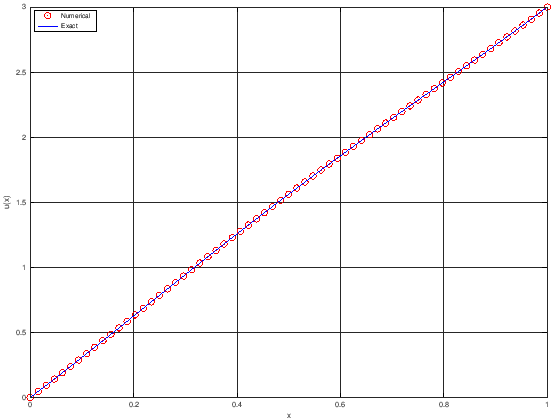

In [4]:
u_exact = @(x) x.^4 - 2*x.^3 + x.^2 + 3*x;
U_exact_final1 = u_exact(x_final1);
err_fact2 = max(abs(U_final1 - U_exact_final1));
fprintf('Фактическая погрешность: %.6e\n', err_fact2);
fprintf('Оценка погрешности по Рунге: %.6e\n', err_est);

plot(x_final1, U_final1, 'ro', x_final1, u_exact(x_final1), 'b-');
xlabel('x'); ylabel('u(x)');
legend('Numerical', 'Exact', 'Location', 'northwest');
grid on;

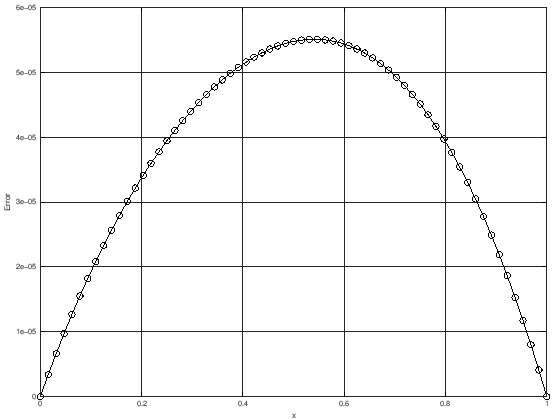

In [5]:
plot(x_final1, abs(U_final1 - u_exact(x_final1)), 'k-o');
xlabel('x'); ylabel('Error');
grid on;

In [6]:
function x = tridiag_solve(a, b, c, d)
    n = length(d);
    for i = 2:n
        w = a(i-1) / b(i-1);
        b(i) = b(i) - w * c(i-1);
        d(i) = d(i) - w * d(i-1);
    end
    x = zeros(n,1);
    x(n) = d(n) / b(n);
    for i = n-1:-1:1
        x(i) = (d(i) - c(i) * x(i+1)) / b(i);
    end
end

a = 0; b = 1;
k = @(x) x.^2 + 1;
q = @(x) 10*(x + 1);
f = @(x) 10*x.^5 - 30*x.^4 + 14*x.^3 + 22*x.^2 + 36*x - 2;

u_exact = @(x) x.^4 - 2*x.^3 + x.^2 + 3*x;

gamma = 3;
delta = 3;

tol = 1e-4;
N = 5;
err_est1 = tol + 1;
first = true;

while err_est1 > tol
    h = (b - a)/(N - 1);
    x = linspace(a, b, N)';
    xmid = (x(1:end-1) + x(2:end))/2;
    
    kmid = k(xmid);
    qv = q(x);
    fv = f(x);
    
    a_diag = zeros(N,1);
    b_diag = zeros(N,1);
    c_diag = zeros(N,1);
    d_vec = zeros(N,1);
    
    for i = 2:N-1
        a_diag(i-1) = -kmid(i-1)/h^2;
        c_diag(i)   = -kmid(i)/h^2;
        b_diag(i)   = (kmid(i-1) + kmid(i))/h^2 + qv(i);
        d_vec(i)    = fv(i);
    end
    
    k_minus_half = k(a - h/2);
    k_plus_half  = k(a + h/2);
    b_diag(1) = (k_minus_half + k_plus_half)/h^2 + qv(1);
    c_diag(1) = -(k_minus_half + k_plus_half)/h^2;
    d_vec(1)  = fv(1) + 2*k_minus_half/h * gamma;
    
    k_minus_half = k(b - h/2);
    k_plus_half  = k(b + h/2);
    a_diag(N-1) = -(k_minus_half + k_plus_half)/h^2;
    b_diag(N)   = (k_minus_half + k_plus_half)/h^2 + qv(N);
    d_vec(N)    = fv(N) + 2*k_plus_half/h * delta;
    
    aa = a_diag(1:N-1);
    cc = c_diag(1:N-1);

    A_full = diag(aa, -1) + diag(b_diag) + diag(cc, 1);
    cond_num = cond(A_full);
    fprintf('N = %d, h = %.6f, cond = %.4e\n', N, h, cond_num);

    U = tridiag_solve(aa, b_diag, cc, d_vec);
    
    if ~first
        U_coarse = U(1:2:end);
        err_est1 = max(abs(U_coarse - U_prev)) / 3;
        if err_est1 < tol
            x_final2 = x;
            U_final2 = U;
            break;
        end
    else
        first = false;
    end
    
    U_prev = U;
    N = 2*N - 1;
end

x_final2 = x;
U_final2 = U;

N = 5, h = 0.250000, cond = 9.3596e+00
N = 9, h = 0.125000, cond = 3.4540e+01
N = 17, h = 0.062500, cond = 1.3776e+02
N = 33, h = 0.031250, cond = 5.5758e+02
N = 65, h = 0.015625, cond = 2.2555e+03
N = 129, h = 0.007812, cond = 9.0944e+03
N = 257, h = 0.003906, cond = 3.6565e+04


Оценка погрешности по Рунге: 2.596786e-05
Фактическая погрешность: 1.744341e+00


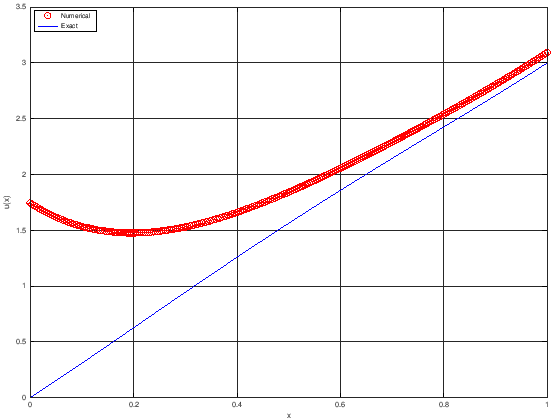

In [7]:
fprintf('Оценка погрешности по Рунге: %.6e\n', err_est1);
u_exact = @(x) x.^4 - 2*x.^3 + x.^2 + 3*x;
U_exact_final2 = u_exact(x_final2);
err_fact2 = max(abs(U_final2 - U_exact_final2));
fprintf('Фактическая погрешность: %.6e\n', err_fact2);

error_U = abs(U_final2 - U_exact_final2);

plot(x_final2, U_final2, 'ro', x_final2, u_exact(x_final2), 'b-');
xlabel('x'); ylabel('u(x)');
legend('Numerical', 'Exact', 'Location', 'northwest');
grid on;

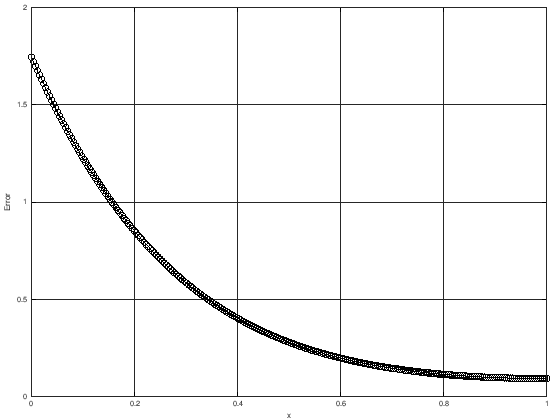

In [8]:
plot(x_final2, abs(U_final2 - u_exact(x_final2)), 'k-o');
xlabel('x'); ylabel('Error');
grid on;

In [9]:
U_final2

U_final2 =

   1.7443
   1.7328
   1.7215
   1.7105
   1.6998
   1.6894
   1.6793
   1.6694
   1.6599
   1.6506
   1.6416
   1.6328
   1.6243
   1.6161
   1.6082
   1.6005
   1.5931
   1.5859
   1.5790
   1.5723
   1.5659
   1.5597
   1.5538
   1.5481
   1.5427
   1.5374
   1.5324
   1.5277
   1.5232
   1.5189
   1.5148
   1.5109
   1.5073
   1.5039
   1.5006
   1.4976
   1.4948
   1.4922
   1.4899
   1.4877
   1.4857
   1.4839
   1.4823
   1.4809
   1.4797
   1.4786
   1.4778
   1.4771
   1.4766
   1.4763
   1.4761
   1.4762
   1.4764
   1.4767
   1.4773
   1.4780
   1.4788
   1.4799
   1.4810
   1.4824
   1.4838
   1.4855
   1.4873
   1.4892
   1.4912
   1.4935
   1.4958
   1.4983
   1.5009
   1.5037
   1.5066
   1.5096
   1.5127
   1.5160
   1.5194
   1.5229
   1.5266
   1.5303
   1.5342
   1.5382
   1.5423
   1.5465
   1.5509
   1.5553
   1.5598
   1.5645
   1.5692
   1.5741
   1.5790
   1.5841
   1.5892
   1.5944
   1.5998
   1.6052
   1.6107
   1.6163
   1.6220
   1.6277
   1.633

In [10]:
U_exact_final2

U_exact_final2 =

        0
   0.0117
   0.0235
   0.0353
   0.0471
   0.0590
   0.0708
   0.0827
   0.0947
   0.1066
   0.1186
   0.1306
   0.1426
   0.1547
   0.1667
   0.1788
   0.1909
   0.2031
   0.2152
   0.2274
   0.2396
   0.2518
   0.2640
   0.2762
   0.2885
   0.3007
   0.3130
   0.3253
   0.3376
   0.3499
   0.3623
   0.3746
   0.3870
   0.3993
   0.4117
   0.4241
   0.4365
   0.4489
   0.4613
   0.4737
   0.4861
   0.4986
   0.5110
   0.5234
   0.5359
   0.5483
   0.5608
   0.5732
   0.5857
   0.5982
   0.6106
   0.6231
   0.6356
   0.6480
   0.6605
   0.6730
   0.6855
   0.6979
   0.7104
   0.7229
   0.7353
   0.7478
   0.7602
   0.7727
   0.7852
   0.7976
   0.8101
   0.8225
   0.8349
   0.8474
   0.8598
   0.8722
   0.8846
   0.8970
   0.9094
   0.9218
   0.9342
   0.9466
   0.9589
   0.9713
   0.9837
   0.9960
   1.0083
   1.0207
   1.0330
   1.0453
   1.0576
   1.0699
   1.0821
   1.0944
   1.1067
   1.1189
   1.1311
   1.1433
   1.1556
   1.1677
   1.1799
   1.1921
  

In [15]:
function x = tridiag_solve(a, b, c, d)
    n = length(d);
    for i = 2:n
        w = a(i-1) / b(i-1);
        b(i) = b(i) - w * c(i-1);
        d(i) = d(i) - w * d(i-1);
    end
    x = zeros(n,1);
    x(n) = d(n) / b(n);
    for i = n-1:-1:1
        x(i) = (d(i) - c(i) * x(i+1)) / b(i);
    end
end

a = 0; b = 1;
k = @(x) x.^2 + 1;
q = @(x) x + 1;
f = @(x) x.^5 - 21*x.^4 + 23*x.^3 - 14*x.^2 + 9*x - 2;

u_exact = @(x) x.^4 - 2*x.^3 + x.^2 + 3*x;

alpha0 = 1; alpha1 = 1; gamma_a = 3;
beta0  = 2; beta1  = 1; gamma_b = 9;

tol = 1e-4;
N = 5;
err_est = tol + 1;
first = true;

while err_est > tol
    h = (b - a)/(N - 1);
    x = linspace(a, b, N)';
    xmid = (x(1:end-1) + x(2:end))/2;
    
    kmid = k(xmid);
    qv = q(x);
    fv = f(x);
    
    a_diag = zeros(N,1);
    b_diag = zeros(N,1);
    c_diag = zeros(N,1);
    d_vec = zeros(N,1);
    
    for i = 2:N-1
        a_diag(i-1) = -kmid(i-1)/h^2;
        c_diag(i)   = -kmid(i)/h^2;
        b_diag(i)   = (kmid(i-1) + kmid(i))/h^2 + qv(i);
        d_vec(i)    = fv(i);
    end
    
    k_minus_half = k(a - h/2);
    k_plus_half  = k(a + h/2);
    b_diag(1) = (k_minus_half + k_plus_half)/h^2 + qv(1) + 2*k_minus_half*alpha0/(h*alpha1);
    c_diag(1) = -(k_minus_half + k_plus_half)/h^2;
    d_vec(1)  = fv(1) + 2*k_minus_half/(h*alpha1)*gamma_a;
    
    k_minus_half = k(b - h/2);
    k_plus_half  = k(b + h/2);
    a_diag(N-1) = -(k_minus_half + k_plus_half)/h^2;
    b_diag(N)   = (k_minus_half + k_plus_half)/h^2 + qv(N) + 2*k_plus_half*beta0/(h*beta1);
    d_vec(N)    = fv(N) + 2*k_plus_half/(h*beta1)*gamma_b;
    
    aa = a_diag(1:N-1);
    cc = c_diag(1:N-1);
    
    U = tridiag_solve(aa, b_diag, cc, d_vec);
    
    if ~first
        U_coarse = U(1:2:end);
        err_est = max(abs(U_coarse - U_prev)) / 3;
        if err_est < tol
            x_final3 = x;
            U_final3 = U;
            break;
        end
    else
        first = false;
    end
    
    U_prev = U;
    N = 2*N - 1;
end

x_final3 = x;
U_final3 = U;

Оценка погрешности по Рунге: 6.182502e-05
Фактическая погрешность: 2.498698e+00


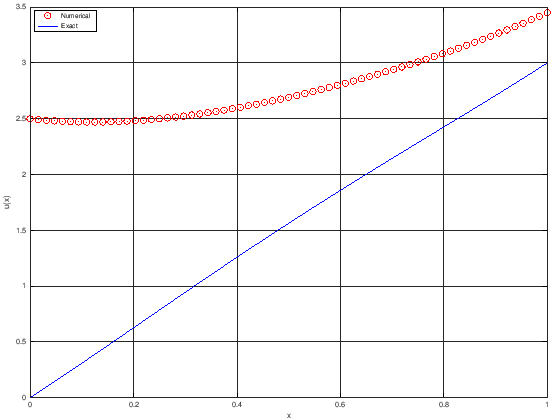

In [16]:
fprintf('Оценка погрешности по Рунге: %.6e\n', err_est);
u_exact = @(x) x.^4 - 2*x.^3 + x.^2 + 3*x;
U_exact_final3 = u_exact(x_final3);
err_fact3 = max(abs(U_final3 - U_exact_final3));
fprintf('Фактическая погрешность: %.6e\n', err_fact3);

plot(x_final3, U_final3, 'ro', x_final3, u_exact(x_final3), 'b-');
xlabel('x'); ylabel('u(x)');
legend('Numerical', 'Exact', 'Location', 'northwest');
grid on;

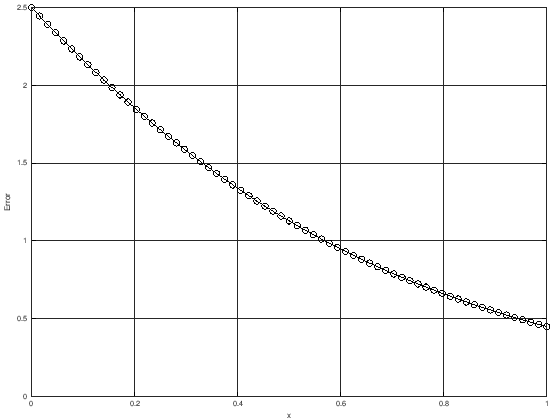

In [17]:
plot(x_final3, abs(U_final3 - u_exact(x_final3)), 'k-o');
xlabel('x'); ylabel('Error');
grid on;

In [14]:
h = 0.007812;  % шаг с последней итерации
gamma = 3;
delta = 3;

% Проверка левого граничного уравнения (i=0)
k_minus_half = (a - h/2)^2 + 1;
k_plus_half = (a + h/2)^2 + 1;
q0 = 10*(a + 1);
f0 = 10*a^5 - 30*a^4 + 14*a^3 + 22*a^2 + 36*a - 2;

u0_exact = a^4 - 2*a^3 + a^2 + 3*a;
u1_exact = (a+h)^4 - 2*(a+h)^3 + (a+h)^2 + 3*(a+h);

C0 = (k_minus_half + k_plus_half)/h^2 + q0;
B0 = -(k_minus_half + k_plus_half)/h^2;
F0 = f0 + 2*k_minus_half/h * gamma;

left0 = C0*u0_exact + B0*u1_exact;
fprintf('ЛЕВОЕ ГРАНИЧНОЕ УРАВНЕНИЕ \n');
fprintf('C0*u0 + B0*u1 = %.10f\n', left0);
fprintf('F0 = %.10f\n', F0);
fprintf('Разница: %.10e\n\n', left0 - F0);

% Проверка правого граничного уравнения (i=n)
k_minus_half = (b - h/2)^2 + 1;
k_plus_half = (b + h/2)^2 + 1;
qn = 10*(b + 1);
fn = 10*b^5 - 30*b^4 + 14*b^3 + 22*b^2 + 36*b - 2;

un_exact = b^4 - 2*b^3 + b^2 + 3*b;
un_1_exact = (b-h)^4 - 2*(b-h)^3 + (b-h)^2 + 3*(b-h);

An = -(k_minus_half + k_plus_half)/h^2;
Cn = (k_minus_half + k_plus_half)/h^2 + qn;
Fn = fn + 2*k_plus_half/h * delta;

leftn = An*un_1_exact + Cn*un_exact;
fprintf('ПРАВОЕ ГРАНИЧНОЕ УРАВНЕНИЕ \n');
fprintf('An*u(n-1) + Cn*un = %.10f\n', leftn);
fprintf('Fn = %.10f\n', Fn);
fprintf('Разница: %.10e\n', leftn - Fn);

ЛЕВОЕ ГРАНИЧНОЕ УРАВНЕНИЕ 
C0*u0 + B0*u1 = -770.0297772394
F0 = 766.0608731459
Разница: -1.5360906504e+03

ПРАВОЕ ГРАНИЧНОЕ УРАВНЕНИЕ 
An*u(n-1) + Cn*un = 1592.1722501437
Fn = 1592.1100282919
Разница: 6.2221851859e-02
